Equilibrium Point: [ 96.54961159  96.91433166 254.30659015]
Eigenvalues: [0.0483642 +0.08442639j 0.0483642 -0.08442639j 0.01392427+0.j        ]
Unstable equilibrium.


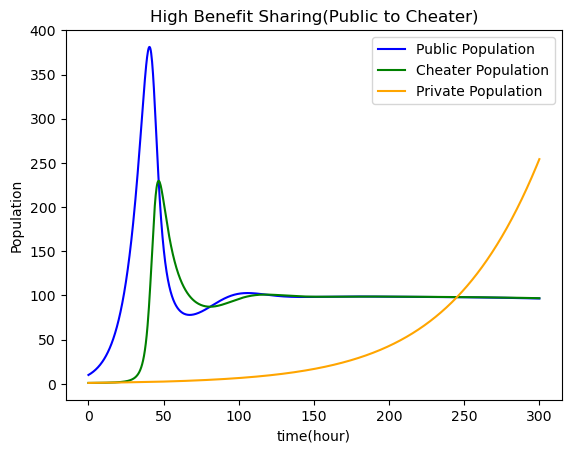

In [3]:
import numpy as np
from scipy.integrate import odeint
from scipy.linalg import eigvals
import matplotlib.pyplot as plt

def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - beta * C * C  # cooperator population
    dDdt = -nu * D * D + alpha * C * D  # defector population
    dPdt = eta * P - beta * C * P - gamma * P * P  # private population

    return dCdt, dDdt, dPdt

def jacobian(y, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    J = np.array([
        [mu - alpha * D - 2 * beta * C, -alpha * C, -beta * C],
        [alpha * D, -nu + alpha * C, 0],
        [-beta * P, 0, eta - beta * C - 2 * gamma * P]
    ])
    return J

# Parameters
beta = 0.00001  # benefit from cooperator to private
gamma = 0.00001  # cost spent by private population
alpha = 0.001  # benefit from cooperator to defector
mu = .1 # growth rate (benefit) of cooperator
eta = .02  # growth rate (benefit) of private
nu = 0.001  # transportation cost of defector

# Initial conditions
C0, D0, P0 = 10.0, 1.0, 1.0
y0 = C0, D0, P0

# Time grid
t = np.linspace(0, 300, 1000)

# Integrate the equations over the time grid, t.
ret = odeint(deriv, y0, t, args=(nu, beta, alpha, mu, gamma, eta))

# Get the equilibrium point (last point of the integration)
equilibrium_point = ret[-1]

# Calculate Jacobian matrix at equilibrium point
Jacobian_matrix = jacobian(equilibrium_point, nu, beta, alpha, mu, gamma, eta)

# Calculate eigenvalues of the Jacobian matrix
eigenvalues = eigvals(Jacobian_matrix)

# Display the equilibrium point and eigenvalues
print("Equilibrium Point:", equilibrium_point)
print("Eigenvalues:", eigenvalues)

# Check stability conditions
real_parts = np.real(eigenvalues)
if all(real_parts < 0):
    print("Stable equilibrium.")
else:
    print("Unstable equilibrium.")

# Plot the results
C, D, P = ret.T
def plotgame(t, C, D, P):
    f, ax = plt.subplots()
    ax.plot(t, C, 'b', label='Public Population')
    ax.plot(t, D, 'g', label='Cheater Population')
    ax.plot(t, P, 'orange', label='Private Population')
    plt.tick_params(axis='y')
    plt.tick_params(axis='x')
    plt.xlabel('time(hour)')
    plt.ylabel('Population')
    legend = ax.legend()

plotgame(t, C, D, P)
plt.title('High Benefit Sharing(Public to Cheater)')
plt.show()
